# 🧠 Théorie de la classification automatique

Ce notebook introduit les concepts fondamentaux de la classification automatique. il est destiné à un public débutant.

---

## 1. C'est quoi la classification ?

### 1.1 Idée générale
La classification est une tâche consistant à attribuer une catégorie à des observations. Par exemple: Déterminer si l'image dépicte un chien ou un chat.

En programmation, il est possible de créer des modèles, qu'on appelle des classificateurs, pour effectuer la tâche de classification.

### 1.2 Exemples du quotidien

Dans la vie de tout les jours, ces modèles sont très couramment utilisés. Voici quelques exemples de classificateurs courants:

- 📧 **Filtre anti-spam** : classer un courriel comme *spam* ou *non-spam*
- 🏥 **Diagnostic médical** : prédire si une tumeur est *maligne* ou *bénigne*
- 🖼️ **Reconnaissance d'images** : identifier si une photo contient un *chat*, un *chien* ou un *oiseau*
- 💳 **Détection de fraude** : repérer des transactions *frauduleuses* parmi des millions de transactions normales
- 🌾 **Agriculture durable** : prédire quel type de sol convient à une culture donnée

### 1.3 Comment sont-ils créés?

Pour y arriver, les classificateurs doivent être entrainés. Le mot entraîné signifie qu'on lui montre un grand nombre d'exemples déjà étiquetés, c'est-à-dire des exemples dont on connaît déjà la bonne réponse. Par exemple, pour entraîner un filtre anti-spam, on lui montre des milliers de courriels déjà identifiés comme spam ou non-spam. Le modèle apprend alors à reconnaître les patterns qui distinguent les deux catégories, pour ensuite être capable de classer de nouveaux courriels qu'il n'a jamais vus.

Ce type d'apprentissage est appelé de l'apprentissage supervisé.

### 1.4 Classification vs Régression

Avant d'aller plus loin, il importe de faire la différence entre un modèle de **classification** et un modèle de **régression**, une autre tâche d'apprentissage supervisée. En effet, bien qu'il ne soit pas rare de comparer la tâche de classification à celle de régression, les deux diffèrent par la nature de ce que nous cherchons à prédire :

|                    | Classification       | Régression                |
|--------------------|----------------------|---------------------------|
| **Variable cible** | Discrète (catégorie) | Continue (nombre)         |
| **Exemple** | Spam ou pas spam ? | Quel est le prix de cette maison ? |
| **Sortie** | Une étiquette de classe      | Une valeur numérique      |

---

## 2. Les données en classification

Pour entraîner un modèle de classification, il faut organiser les observations de manière structurée.

Chaque observation est décrite par deux éléments:

- **X** (les features) : les caractéristiques mesurées pour chaque observation (ex: taille, poids, couleur)
- **y** (les labels) : l'étiquette associée à chaque observation (ex: chat, chien)

Autrement dit, pour chaque donnée, X contient l'information et y correspond à la réponse attendue.

Le modèle apprend alors à faire le lien entre X → y, c’est-à-dire entre les caractéristiques et la bonne catégorie.

### 2.1 Séparation des données
Pour évaluer correctement un modèle, on ne peut pas utiliser toutes les données pour l'entrainement. On les divise donc en deux ensembles:
- **Entraînement (train)** : le modèle apprend la relation entre X et y à partir de ces données
- **Test** : on évalue la performance du modèle sur des données qu'il n'a jamais vues

Il est crucial que le modèle ne voie **jamais** les données de test pendant l'entraînement. Sinon, on ne peut pas savoir s'il a vraiment appris à généraliser.

### 2.2 Pourquoi c’est important ?

Un modèle peut sembler très performant s’il est évalué sur les mêmes données que celles utilisées pour l’entraîner.
Cependant, cette performance est souvent trompeuse.

Ce qu’on veut réellement mesurer, c’est sa capacité à bien fonctionner sur des données qu’il n’a jamais vues.

C’est précisément le rôle de l’ensemble de test.

---

## 3. Les différents types de classification

Les problèmes de classification ne sont pas tous identiques.
Il en existe plusieurs types selon le nombre de classes et leur structure.

### 2.1 Classification binaire

C'est la forme la plus simple : les données sont divisées en **deux catégories mutuellement exclusives**. Le modèle doit décider dans laquelle des deux classes tombe chaque observation. En d'autres mots, chaque observation appartien à une seule des deux classes possibles, qui sont mutuellement exclusives. 

- Exemples : spam/non-spam, malade/sain, fraude/non-fraude
- Algorithmes naturellement binaires : régression logistique, SVM

Généralement, ce genre de modèle apprend essentiellement à déterminer une frontière de décision qui sépare les deux classes.

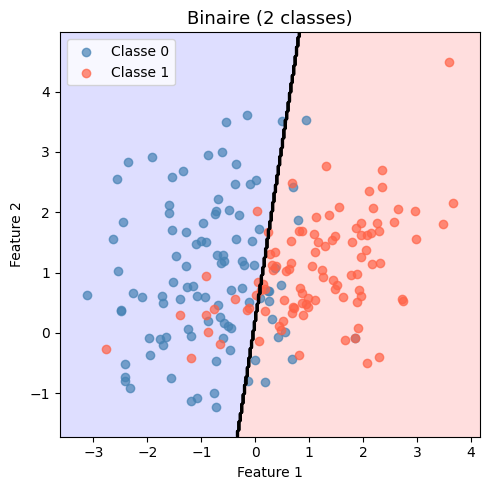

In [7]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

X_bin, y_bin = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                    n_informative=2, n_clusters_per_class=1, random_state=42)

# --- Entraîner un SVM pour obtenir la frontière ---
clf = SVC(kernel='linear')
clf.fit(X_bin, y_bin)

# --- Créer la grille pour tracer la frontière ---
x_min, x_max = X_bin[:, 0].min() - 0.5, X_bin[:, 0].max() + 0.5
y_min, y_max = X_bin[:, 1].min() - 0.5, X_bin[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.15, cmap='bwr')
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)
plt.scatter(X_bin[y_bin==0, 0], X_bin[y_bin==0, 1], color='steelblue', label='Classe 0', alpha=0.7)
plt.scatter(X_bin[y_bin==1, 0], X_bin[y_bin==1, 1], color='tomato', label='Classe 1', alpha=0.7)
plt.title('Binaire (2 classes)', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Classification multiclasse

Comme son nom l'indique, ce type de classificateur est utile lorsqu'il y a **plus de deux classes**, mais chaque observation n'appartient qu'à **une seule classe** à la fois.

- Exemples : identifier l'espèce d'un animal (chat, chien, oiseau), reconnaître un chiffre écrit à la main (0 à 9)

Certains algorithmes sont naturellements binaires et doivent être adaptés pour faire de la classification multi-classe!
- **One-vs-Rest (OvR)**:
  - On entraine $N$ modèles ( 1 par classe)
  - Chaque modèle apprend à distinguer *une classe vs toutes les autres*
  - Prédiction = On choisit la classe avec la plus forte probabilité
- **One-vs-One (OvO)** : 
  - On entraine un modèle pour chaque *paire de classes*
  - Donc on a $\frac{N(N-1)}{2}$ modèles
  - Prédiction = vote majoritaire entre les modèles

Remarque importante

Certains modèles gèrent directement le multiclasse (ex : arbres de décision, réseaux de neurones), sans passer par ces stratégies.

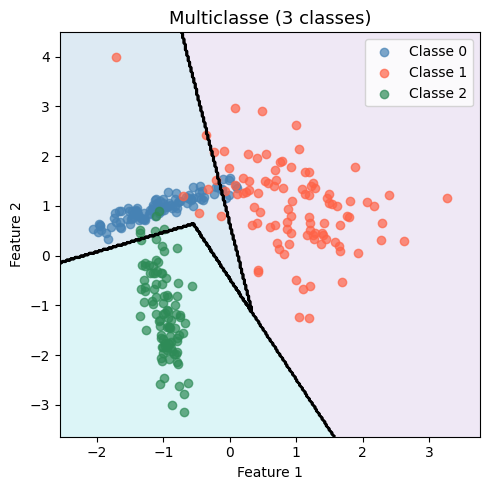

In [8]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

X_multi, y_multi = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                        n_informative=2, n_classes=3,
                                        n_clusters_per_class=1, random_state=42)

# --- Entraîner un SVM multiclasse ---
clf = SVC(kernel='linear')
clf.fit(X_multi, y_multi)

# --- Créer la grille pour tracer la frontière ---
x_min, x_max = X_multi[:, 0].min() - 0.5, X_multi[:, 0].max() + 0.5
y_min, y_max = X_multi[:, 1].min() - 0.5, X_multi[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

colors_multi = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.15, cmap='tab10')
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)
for c in range(3):
    plt.scatter(X_multi[y_multi==c, 0], X_multi[y_multi==c, 1],
                color=colors_multi[c], label=f'Classe {c}', alpha=0.7)
plt.title('Multiclasse (3 classes)', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 Classification multi-label

Dans ce cas, Une observation peut appartenir à **plusieurs classes simultanément**. Les classes ne sont pas mutuellement exclusives.

- Exemples : un film peut être à la fois *action* et *comédie*, un article peut traiter de *politique* et d'*économie*

Donc, au lieu d'une seule étiquette, on utilise souvent un vecteur de labels:
- Exemple = 1, Comédie = 1, Drame = 0 → [1, 1, 0]

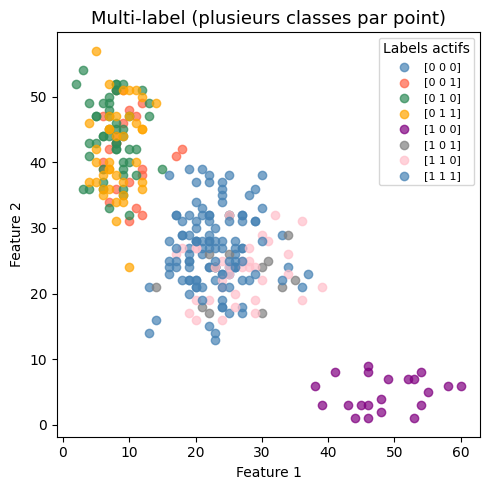

In [9]:
from sklearn.datasets import make_multilabel_classification
import matplotlib.pyplot as plt
import numpy as np

X_ml, y_ml = make_multilabel_classification(n_samples=300, n_features=2, 
                                             n_classes=3, n_labels=2,
                                             random_state=42)

# --- Couleur différente pour chaque combinaison de labels ---
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple', 'grey', 'pink']
labels_unique = np.unique(y_ml, axis=0)

plt.figure(figsize=(5, 5))
for i, label_combo in enumerate(labels_unique):
    mask = np.all(y_ml == label_combo, axis=1)
    plt.scatter(X_ml[mask, 0], X_ml[mask, 1],
                color=colors[i % len(colors)],
                label=str(label_combo),
                alpha=0.7)

plt.title('Multi-label (plusieurs classes par point)', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Labels actifs', fontsize=8)
plt.tight_layout()
plt.show()

| Type        | Nombre de classes possibles | Nombre de labels par observation |
| ----------- | ------------- | ------------------ |
| Binaire     | 2             | 1                  |
| Multiclasse | 3 ou plus     | 1                  |
| Multi-label | 2 ou plus     | 1 ou plusieurs     |


## 3. Comment fonctionne la classification ?
En général, un projet de classification suit une série d'étapes qui permettent de passer des données brutes à un modèle capable de faire des prédictions fiables. Cette série d'étape est généralement appelé un pipeline. Voici un pipeline typique:  

### **3.1 Collecte de données :**  

On rassemble un ensemble de données contenant à la fois :
- les **caractéristiques** (X)
- les **étiquettes** (y)  

La qualité des données est cruciale : un modèle ne peut pas apprendre correctement à partir de données biaisées ou incomplètes.

### **3.2 Sélection et extraction des features :**  

L’objectif de cette étape est d’identifier les caractéristiques qui permettent réellement de distinguer les classes et de se débarasser de celles dont nous n'aurons pas besoin.

Cela peut inclure :  
-  Supprimer des variables inutiles
-  Créer de nouvelles variables plus informatives
-  Transformer des données (ex : texte → vecteurs numériques)

### **3.3 Prétraitement des données :**  

Les données doivent souvent être préparées avant de pouvoir entrainer le modèle. Cela inclut des étapes comme :

- La gestion des valeurs manquantes
- La normalisation / standardisation
- L'encodage des variables catégorielles
- La réduction de dimension (ex : PCA)

Cette étape permet de rendre les données compatibles et optimales pour le modèle. Évidemment, cette étape diffère énormément dépendant du type de données utilisés. Par exemple, la classification de mots va demander des techniques de pré-traitement très différente que la classification d'images.

### **3.4 Entraînement du modèle :**

Une fois les données pré-traitées, nous pouvons entrainer le modèle! Celui-ci apprend à partir des données d’entraînement en trouvant des patterns reliant X (caractéristiques) à y (étiquettes).

Concrètement, à travers l'entrainement, le modèle ajuste ses paramètres pour minimiser l’erreur de prédiction.

### **3.5 Évaluation du modèle**

Une fois entrainé, le modèle est testé sur les données test. Ces données n'ont jamais été vu par le modèle. C'est lors de cette étape qu'on apprends si les paramètres ajustés permettent bel et bien de classer les observations comme il le faut.

On utilise des métriques comme :

- Accuracy (taux de bonnes prédictions)
- Précision / rappel
- F1-score

Cela permet de vérifier sa capacité à généraliser.

### **3.6 Prédiction**

Le modèle peut ensuite être utilisé en pratique pour classer de nouvelles données.

### **3.7 Amélioration**

Rarement, un modèle est optimal du premier coup.
On peut l’améliorer en :

- Ajustant les hyperparamètres
- Changeant d’algorithme
- Améliorant les features
- Collectant plus de données

**Un exemple concret d'entrainement de modèle est possible dans un autre notebook!**

---


## 4. Généralisation : le compromis biais-variance

Évidemment, les modèles entrainés ne sont jamais parfait. Qui plus est, un des défis centraux en apprentissage automatique est la **généralisation**. Ce concept revient à se demander:

- est-ce que le modèle apprend réellement ce qui différencie les données, ou est-ce qu’il se contente de mémoriser les données d’entraînement ?

Ce problème se présente généralement sous deux formes: *l'underfitting* et le *overfitting*. Voici leur différence:

### Underfitting
Le modèle est **trop simple** : il ne capture pas les différences dans les données. Il présente donc des mauvaises performances en entraînement **et** en test.

### Overfitting
Le modèle est **trop complexe** : il apprend ce qui différencie les données d'entrainement trop précisément, donc en incluant leur bruit. Cette précision trop grande a comme conséquence qu'il performe très bien sur les données d'entrainement. En revanche, quand vient le temps de tester le modèle sur les données test, le modèle ne généralise pas bien. En d'autres mots, il est trop spécifique pour êter en mesure de bien performer sur les données tests.

### Intuition

On peut voir le compromis biais-variance comme un équilibre :

- Trop simple (underfitting) → le modèle rate l’information importante  
- Trop complexe (overfitting) → le modèle apprend trop de détails inutiles

**L'objectif est de trouver le *bon équilibre* : un modèle assez complexe pour capturer les différences, mais pas trop pour pouvoir être généralisable.**



## 5. Conclusion

Dans ce notebook, nous avons introduit les bases de la classification, qui est une tâche centrale en apprentissage supervisé. Nous avons pris le temps de voir comment un modèle est en mesure d'apprendre à associer des caractéristiques (X) à des catégories (y), ainsi que différents types de classification qui existent.

Nous avons ensuite exploré les étapes clés d’un projet de classification, de la collecte des données jusqu’à la prédiction.

Enfin, nous avons introduit la notion de généralisation, un enjeu fondamental. Il faut construire un modèle capable de bien fonctionner sur de nouvelles données, et pas seulement sur celles qu’il a déjà vues.

Dans les prochains notebooks, nous irons plus loin en explorant des exemples algorithmes de classification concrets, ainsi qu'en présentant un exemple.

BIBLIOGRAPHIE

https://www.markdownguide.org/basic-syntax/

https://www.markdownguide.org/extended-syntax/

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html

https://mystmd.org/guide/typography

https://emojipedia.org

https://www.geeksforgeeks.org/machine-learning/getting-started-with-classification/

https://www.datacamp.com/blog/classification-machine-learning

https://c3.ai/glossary/data-science/classifier/

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/cross_validation.html

https://scikit-learn.org/stable/modules/learning_curve.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html
